# Monte Carlo VaR with Financial Modeling Prep (cached data)

This notebook uses cached FMP prices, builds 5 portfolio variants from our CSVs,
and estimates Value-at-Risk (VaR) using a Monte Carlo simulation on CPU and GPU.


## Prerequisites
- Install dependencies: `pip install pandas numpy matplotlib`
- Run `notebooks/data_prep_fmp.ipynb` to populate `data/cache/fmp_prices.csv`
- If you need to refresh prices, set `FMP_API_KEY` and re-run `notebooks/data_prep_fmp.ipynb`


In [5]:
import time
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
pd.set_option("display.width", 120)


## GPU diagnostics
This verifies CuPy sees the GPU. If it fails, CUDA is not available to this kernel.


In [6]:
try:
    import cupy as cp
    device_count = cp.cuda.runtime.getDeviceCount()
    print(f"CuPy OK. GPU count: {device_count}")
    if device_count == 0:
        raise RuntimeError("CuPy installed but no GPUs detected.")
    print(f"GPU 0: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
except Exception as exc:
    raise RuntimeError(f"CuPy/CUDA not usable: {exc}")


CuPy OK. GPU count: 1
GPU 0: NVIDIA L4


## Load cached prices and portfolios
We use cached adjusted close prices and the 5 portfolio CSVs in `notebooks/`.


In [7]:
repo_root = Path.cwd()
if (repo_root / "notebooks").exists():
    portfolio_dir = repo_root / "notebooks"
    price_candidates = [
        repo_root / "data" / "cache" / "fmp_prices.csv",
        repo_root / "notebooks" / "data" / "cache" / "fmp_prices.csv",
    ]
else:
    # If running from within notebooks/, fall back to local paths
    portfolio_dir = repo_root
    price_candidates = [
        repo_root.parent / "data" / "cache" / "fmp_prices.csv",
        repo_root / "data" / "cache" / "fmp_prices.csv",
    ]

PORTFOLIO_FILES = [
    str(portfolio_dir / "portfolio_1.csv"),
    str(portfolio_dir / "portfolio_2.csv"),
    str(portfolio_dir / "portfolio_3.csv"),
    str(portfolio_dir / "portfolio_4.csv"),
    str(portfolio_dir / "portfolio_5.csv"),
]

prices_path = next((p for p in price_candidates if p.exists()), None)
if prices_path is None:
    checked = ", ".join(str(p) for p in price_candidates)
    raise RuntimeError(f"Cached prices not found. Checked: {checked}. Run data_prep_fmp.ipynb first.")

prices = pd.read_csv(prices_path, parse_dates=["date"]).set_index("date")

def load_portfolio(path, columns):
    df = pd.read_csv(path)
    if set(df.columns) != {"ticker", "weight"}:
        raise ValueError(f"Expected columns ticker,weight in {path}")
    missing = set(df["ticker"]) - set(columns)
    if missing:
        raise ValueError(f"Tickers missing in price data: {sorted(missing)}")
    return df

portfolios = {path: load_portfolio(path, prices.columns) for path in PORTFOLIO_FILES}

prices.head()


,AAPL,ABBV,AMZN,AVGO,BRK.B,COST,GOOGL,HD,JNJ,JPM,LLY,MA,META,MSFT,NVDA,PG,TSLA,UNH,V,XOM
date,,,,,,,,,,,,,,,,,,,,
2024-01-10,186.19,164.89,153.73,108.06,367.92,672.76,142.28,356.80,161.87,171.02,630.19,428.27,370.47,382.77,54.35,149.94,233.94,537.64,264.56,98.69
2024-01-11,185.59,163.78,155.18,110.00,363.34,673.58,142.08,356.53,161.15,170.30,635.72,426.72,369.67,384.63,54.82,150.51,227.22,539.68,264.03,98.67
2024-01-12,185.92,162.40,154.62,110.77,363.62,683.24,142.65,355.71,162.39,169.05,642.92,429.10,374.49,388.47,54.71,150.60,218.89,521.51,264.17,99.95
2024-01-16,183.63,161.48,153.16,111.50,361.10,681.49,142.49,358.43,160.52,167.99,634.57,428.35,367.46,390.27,56.38,149.79,219.91,519.15,265.24,97.69
2024-01-17,182.68,162.04,151.71,110.37,359.29,684.19,141.47,355.70,160.43,167.09,628.91,427.42,368.37,389.47,56.05,149.94,215.55,524.94,266.63,96.98


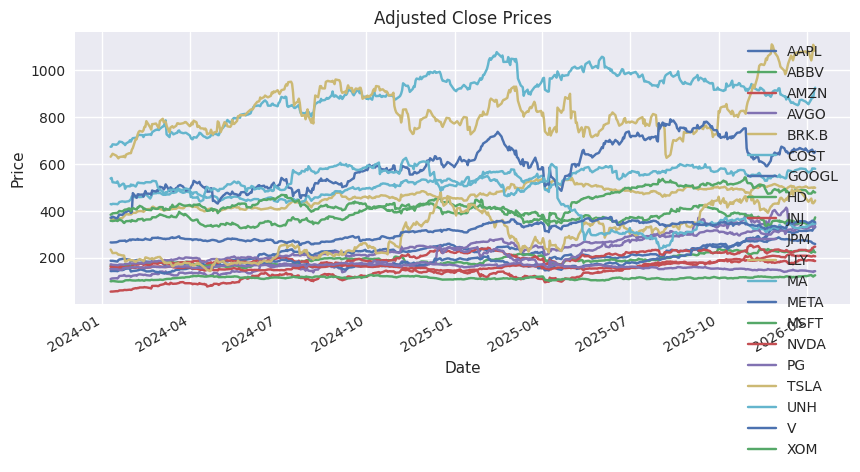

In [8]:
prices.plot(figsize=(10, 4), title="Adjusted Close Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


## Build 5-portfolio weights
Load weights from the 5 portfolio CSVs and select one for the single-portfolio VaR demo.


In [9]:
portfolio_names = [Path(p).stem for p in PORTFOLIO_FILES]
weights_matrix = []
for path in PORTFOLIO_FILES:
    df = portfolios[path].set_index("ticker").loc[prices.columns]
    weights_matrix.append(df["weight"].values)
weights_matrix = np.vstack(weights_matrix)

PORTFOLIO_INDEX = 0  # portfolio_1.csv
weights = weights_matrix[PORTFOLIO_INDEX]
weights


array([0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05])

## Compute returns
We will use daily log returns for the simulation.


In [10]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.head()


,AAPL,ABBV,AMZN,AVGO,BRK.B,COST,GOOGL,HD,JNJ,JPM,LLY,MA,META,MSFT,NVDA,PG,TSLA,UNH,V,XOM
date,,,,,,,,,,,,,,,,,,,,
2024-01-11,-0.003228,-0.006755,0.009388,0.017794,-0.012526,0.001218,-0.001407,-0.000757,-0.004458,-0.004219,0.008737,-0.003626,-0.002162,0.004848,0.008610,0.003794,-0.029146,0.003787,-0.002005,-0.000203
2024-01-12,0.001777,-0.008462,-0.003615,0.006976,0.000770,0.014239,0.004004,-0.002303,0.007665,-0.007367,0.011262,0.005562,0.012954,0.009934,-0.002009,0.000598,-0.037349,-0.034248,0.000530,0.012889
2024-01-16,-0.012394,-0.005681,-0.009487,0.006569,-0.006954,-0.002565,-0.001122,0.007618,-0.011582,-0.006290,-0.013073,-0.001749,-0.018951,0.004623,0.030068,-0.005393,0.004649,-0.004536,0.004042,-0.022871
2024-01-17,-0.005187,0.003462,-0.009512,-0.010186,-0.005025,0.003954,-0.007184,-0.007646,-0.000561,-0.005372,-0.008959,-0.002173,0.002473,-0.002052,-0.005870,0.001001,-0.020025,0.011091,0.005227,-0.007294
2024-01-18,0.032051,0.007746,0.011730,0.035775,0.008564,0.004550,0.014108,0.006166,0.004850,0.001973,-0.008880,0.007691,0.020847,0.011234,0.018735,-0.012077,-0.017173,-0.016519,0.005647,-0.001858


## Monte Carlo VaR
We simulate correlated returns using the historical mean and covariance.
Change `NUM_SIMULATIONS`, `HORIZON_DAYS`, and `CONFIDENCE` as needed.


In [11]:
NUM_SIMULATIONS = 2_000_000
HORIZON_DAYS = 10
CONFIDENCE = 0.95
USE_GPU = True  # requires cupy in the environment
# Ensure cupy is defined for this cell
try:
    import cupy as cp
except Exception:
    cp = None


mu = log_returns.mean().values
cov = log_returns.cov().values

def simulate_var(num_simulations, horizon_days, weights, mu, cov, use_gpu=True):
    if use_gpu and cp is None:
        raise RuntimeError("USE_GPU=True but CuPy is not available in this kernel.")
    if use_gpu and cp is not None:
        xp = cp
        backend = "cuda"
    else:
        xp = np
        backend = "cpu"

    mu_h = mu * horizon_days
    cov_h = cov * horizon_days

    t0 = time.perf_counter()
    z = xp.random.standard_normal((num_simulations, len(mu))).astype(xp.float32)
    chol = xp.linalg.cholesky(xp.asarray(cov_h, dtype=xp.float32))
    sim = z @ chol.T + xp.asarray(mu_h, dtype=xp.float32)
    port_log_returns = sim @ xp.asarray(weights, dtype=xp.float32)
    port_simple_returns = xp.exp(port_log_returns) - 1.0
    elapsed = time.perf_counter() - t0

    if xp is cp:
        port_simple_returns = cp.asnumpy(port_simple_returns)

    return port_simple_returns, elapsed, backend

port_simple_returns, elapsed, backend = simulate_var(
    NUM_SIMULATIONS, HORIZON_DAYS, weights, mu, cov, USE_GPU
)

var_level = 1.0 - CONFIDENCE
var_value = np.quantile(port_simple_returns, var_level)

print(f"{int(CONFIDENCE*100)}% {HORIZON_DAYS}-day VaR: {abs(var_value):.2%}")
print(f"Simulations: {NUM_SIMULATIONS:,} | Backend: {backend} | Elapsed: {elapsed:.3f}s")


95% 10-day VaR: 4.21%
Simulations: 2,000,000 | Backend: cuda | Elapsed: 0.639s


In [12]:
# Compare CPU vs GPU (accuracy + performance)
NUM_SIMULATIONS_COMPARE = 20_000_000
HORIZON_DAYS_COMPARE = HORIZON_DAYS
CONFIDENCE_COMPARE = CONFIDENCE

# Note: increase NUM_SIMULATIONS_COMPARE if your GPU has enough memory.
cpu_returns, cpu_elapsed, _ = simulate_var(
    NUM_SIMULATIONS_COMPARE, HORIZON_DAYS_COMPARE, weights, mu, cov, use_gpu=False
)
gpu_returns, gpu_elapsed, gpu_backend = simulate_var(
    NUM_SIMULATIONS_COMPARE, HORIZON_DAYS_COMPARE, weights, mu, cov, use_gpu=True
)

cpu_var = np.quantile(cpu_returns, 1.0 - CONFIDENCE_COMPARE)
gpu_var = np.quantile(gpu_returns, 1.0 - CONFIDENCE_COMPARE)

cpu_mean = float(np.mean(cpu_returns))
gpu_mean = float(np.mean(gpu_returns))

print(f"CPU: VaR={abs(cpu_var):.2%} | mean={cpu_mean:.4%} | time={cpu_elapsed:.3f}s")
print(f"GPU: VaR={abs(gpu_var):.2%} | mean={gpu_mean:.4%} | time={gpu_elapsed:.3f}s | backend={gpu_backend}")
print(f"Speedup (CPU/GPU): {cpu_elapsed / gpu_elapsed:.2f}x" if gpu_elapsed > 0 else "Speedup: n/a")

# Accuracy deltas
print(f"VaR delta (GPU-CPU): {(gpu_var - cpu_var):.6%}")
print(f"Mean delta (GPU-CPU): {(gpu_mean - cpu_mean):.6%}")


CPU: VaR=4.21% | mean=0.8667% | time=8.291s
GPU: VaR=4.21% | mean=0.8650% | time=0.131s | backend=cuda
Speedup (CPU/GPU): 63.30x
VaR delta (GPU-CPU): 0.001734%
Mean delta (GPU-CPU): -0.001672%


## Parallel experiments: many portfolios from the 5 base portfolios

This section builds many portfolios by sampling and perturbing the 5 base portfolios
to highlight GPU throughput on parallel experiments.


In [13]:
# Parallel benchmark settings
N_PORTFOLIOS = 2048
NUM_SIMULATIONS_SCALE = 5_000_000
BATCH_SIZE = 200_000
CONFIDENCE_SCALE = CONFIDENCE

# Ensure cupy is defined for this cell
try:
    import cupy as cp
except Exception:
    cp = None

rng = np.random.default_rng(42)
base_weights = weights_matrix
N_ASSETS = base_weights.shape[1]

# Build many portfolios by sampling the 5 base portfolios and adding small noise
base_idx = rng.integers(0, base_weights.shape[0], size=N_PORTFOLIOS)
weights_matrix_large = base_weights[base_idx].copy()
noise = rng.normal(scale=0.02, size=weights_matrix_large.shape)
weights_matrix_large = np.clip(weights_matrix_large + noise, 0.0, None)
weights_matrix_large /= weights_matrix_large.sum(axis=1, keepdims=True)

mu_scale = log_returns.mean().values
cov_scale = log_returns.cov().values

def z_for_confidence(conf):
    if abs(conf - 0.95) < 1e-6:
        return 1.64485
    if abs(conf - 0.975) < 1e-6:
        return 1.95996
    if abs(conf - 0.99) < 1e-6:
        return 2.32635
    return 1.64485

def simulate_portfolio_stats(num_sim, horizon_days, weights, mu, cov, use_gpu=True, batch_size=200000):
    if use_gpu and cp is not None:
        xp = cp
        backend = "cuda"
    else:
        xp = np
        backend = "cpu"

    mu_h = mu * horizon_days
    cov_h = cov * horizon_days
    chol = xp.linalg.cholesky(xp.asarray(cov_h, dtype=xp.float32))
    w = xp.asarray(weights, dtype=xp.float32)

    sums = xp.zeros(weights.shape[0], dtype=xp.float64)
    sums_sq = xp.zeros(weights.shape[0], dtype=xp.float64)

    t0 = time.perf_counter()
    remaining = num_sim
    while remaining > 0:
        n = min(batch_size, remaining)
        z = xp.random.standard_normal((n, len(mu))).astype(xp.float32)
        sim = z @ chol.T + xp.asarray(mu_h, dtype=xp.float32)
        port = sim @ w.T
        sums += port.sum(axis=0)
        sums_sq += (port * port).sum(axis=0)
        remaining -= n
    elapsed = time.perf_counter() - t0

    if xp is cp:
        sums = cp.asnumpy(sums)
        sums_sq = cp.asnumpy(sums_sq)

    mean = sums / num_sim
    var = sums_sq / num_sim - mean * mean
    std = np.sqrt(np.maximum(var, 0.0))
    z = z_for_confidence(CONFIDENCE_SCALE)
    # Parametric VaR approximation
    var_est = mean - z * std

    return mean, std, var_est, elapsed, backend

cpu_mean, cpu_std, cpu_var_est, cpu_elapsed, _ = simulate_portfolio_stats(
    NUM_SIMULATIONS_SCALE, HORIZON_DAYS, weights_matrix_large, mu_scale, cov_scale, use_gpu=False, batch_size=BATCH_SIZE
)
gpu_mean, gpu_std, gpu_var_est, gpu_elapsed, gpu_backend = simulate_portfolio_stats(
    NUM_SIMULATIONS_SCALE, HORIZON_DAYS, weights_matrix_large, mu_scale, cov_scale, use_gpu=True, batch_size=BATCH_SIZE
)

print(f"CPU: portfolios={N_PORTFOLIOS}, assets={N_ASSETS}, sims={NUM_SIMULATIONS_SCALE:,} | time={cpu_elapsed:.2f}s")
print(f"GPU: portfolios={N_PORTFOLIOS}, assets={N_ASSETS}, sims={NUM_SIMULATIONS_SCALE:,} | time={gpu_elapsed:.2f}s | backend={gpu_backend}")
print(f"Speedup (CPU/GPU): {cpu_elapsed / gpu_elapsed:.2f}x" if gpu_elapsed > 0 else "Speedup: n/a")

# Accuracy comparison (summary stats across portfolios)
print(f"Mean delta (GPU-CPU): {float(np.mean(gpu_mean - cpu_mean)):.6e}")
print(f"Std delta (GPU-CPU): {float(np.mean(gpu_std - cpu_std)):.6e}")
print(f"VaR delta (GPU-CPU): {float(np.mean(gpu_var_est - cpu_var_est)):.6e}")


CPU: portfolios=2048, assets=20, sims=5,000,000 | time=15.14s
GPU: portfolios=2048, assets=20, sims=5,000,000 | time=0.23s | backend=cuda
Speedup (CPU/GPU): 66.39x
Mean delta (GPU-CPU): 3.944785e-06
Std delta (GPU-CPU): 2.758590e-06
VaR delta (GPU-CPU): -5.926810e-07


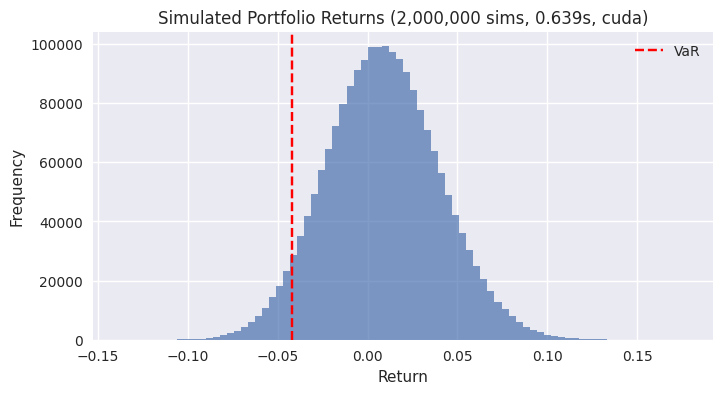

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(port_simple_returns, bins=80, alpha=0.7)
plt.axvline(var_value, color="red", linestyle="--", label="VaR")
plt.title(f"Simulated Portfolio Returns ({NUM_SIMULATIONS:,} sims, {elapsed:.3f}s, {backend})")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()


## Optional: Export results
Save your simulated return distribution for downstream analysis.


In [15]:
output_path = "/home/ubuntu/monte-carlo-GPU-CUDA/results/var_simulated_returns.csv"
pd.Series(port_simple_returns, name="simulated_return").to_csv(output_path, index=False)
print(f"Saved simulated returns to {output_path}")


Saved simulated returns to /home/ubuntu/monte-carlo-GPU-CUDA/results/var_simulated_returns.csv
